/p/project1/westai0065/hierarchical-latent-structures/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Scanning 100 checkpoints for structural probing...


100%|██████████| 100/100 [01:22<00:00,  1.21it/s]


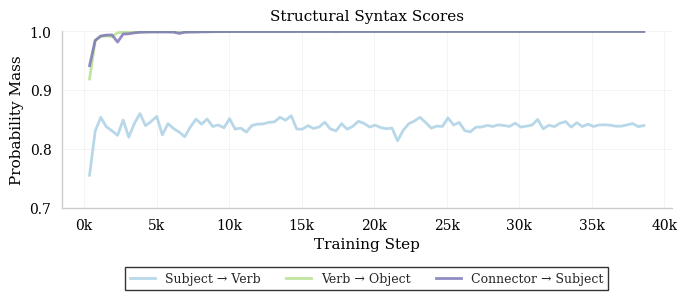

In [1]:
import torch
import numpy as np
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
import importlib

import plot_helpers
importlib.reload(plot_helpers)
from plot_helpers import (
    setup_plotting_style,
    style_ax,
    get_step_formatter,
    save_figure,
    COLOR_NGRAM,
    COLOR_PCFG,
    PAPER_WIDTH_IN,
    PAPER_HEIGHT_IN,
)

setup_plotting_style(style="paper")

import warnings
warnings.filterwarnings('ignore')

EXPERIMENT_DIR = "/p/project1/westai0065/master-thesis/experiments/experiment_hierarchical_final/8a112581-22f5-44e0-bc63-9a6eb4ed1658/checkpoints"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_SAMPLES = 100 

R_SUBJ = range(0, 300)
R_VERB = range(300, 600)
R_OBJ  = range(600, 900)
R_CONN = range(900, 1000)
EOS_TOKEN = 1000

def get_sorted_checkpoints(experiment_dir):
    path = Path(experiment_dir)
    checkpoints = [p for p in path.iterdir() if p.is_dir() and "checkpoint-" in p.name]
    def extract_step(p):
        match = re.search(r"checkpoint-(\d+)", p.name)
        return int(match.group(1)) if match else -1
    return sorted(checkpoints, key=extract_step)

def get_structural_scores(model, num_samples, device):
    subjects = torch.randint(0, 300, (num_samples, 1)).to(device)
    
    with torch.no_grad():
        outputs = model(subjects)
        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        
        verb_mass = probs[:, 300:600].sum(dim=-1).mean().item()

    verbs = torch.randint(300, 600, (num_samples, 1)).to(device)
    sv_input = torch.cat([subjects, verbs], dim=1)
    
    with torch.no_grad():
        outputs = model(sv_input)
        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        
        obj_mass = probs[:, 600:900].sum(dim=-1).mean().item()

    objs = torch.randint(600, 900, (num_samples, 1)).to(device)
    conns = torch.randint(900, 1000, (num_samples, 1)).to(device)
    svoc_input = torch.cat([subjects, verbs, objs, conns], dim=1)
    
    with torch.no_grad():
        outputs = model(svoc_input)
        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        
        reset_mass = probs[:, 0:300].sum(dim=-1).mean().item()

    return verb_mass, obj_mass, reset_mass


checkpoints = get_sorted_checkpoints(EXPERIMENT_DIR)
history_struct = {}

print(f"Scanning {len(checkpoints)} checkpoints for structural probing...")

for cp_path in tqdm(checkpoints):
    step = int(re.search(r"checkpoint-(\d+)", cp_path.name).group(1))
    
    try:
        model = AutoModelForCausalLM.from_pretrained(cp_path, local_files_only=True)
        model.to(DEVICE)
        model.eval()

        s_v, v_o, c_s = get_structural_scores(model, NUM_SAMPLES, DEVICE)
        history_struct[step] = (s_v, v_o, c_s)

        del model
        gc.collect()
        torch.cuda.empty_cache()
        
    except Exception as e:
        print(f"Error at {cp_path.name}: {e}")


steps = sorted(history_struct.keys())
data = np.array([history_struct[s] for s in steps])

def set_black_labels(ax):
    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

fig, ax = plt.subplots(figsize=(PAPER_WIDTH_IN, PAPER_HEIGHT_IN * 0.7))

ax.plot(steps, data[:, 0], 
        linewidth=2.0, alpha=0.8, color=COLOR_NGRAM, label='Subject → Verb')
ax.plot(steps, data[:, 1], 
        linewidth=2.0, alpha=0.8, color=COLOR_PCFG, label='Verb → Object')
ax.plot(steps, data[:, 2], 
        linewidth=2.0, alpha=0.8, color='#7570b3', label='Connector → Subject')

style_ax(ax, xlabel="Training Step", ylabel="Probability Mass", style="paper")
ax.set_title('Structural Syntax Scores', fontsize=11, pad=8, color='black')
ax.legend(frameon=True, fancybox=False, edgecolor='black', fontsize=9, 
          loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3)
ax.xaxis.set_major_formatter(get_step_formatter())
set_black_labels(ax)

ax.set_ylim(0.7, 1.0)

plt.tight_layout()
fig.subplots_adjust(bottom=0.3)
save_figure(fig, "structural_syntax_scores.pdf")
plt.show()